In [1]:
import matplotlib.pyplot as plt
from sklearn import pipeline
from rdkit import Chem
import seaborn as sns
import pandas as pd
import numpy as np
import sklearn
import scipy

In [2]:
df = pd.read_csv("data/processed_dataset_wo_metals.csv")

In [3]:
df.columns

Index(['smiles', 'id', 'energy', 'atomization_energy', 'homo_lumo_gap',
       'ionization_energy', 'electron_affinity', 'chemical_potential',
       'molecular_dipole_norm', 'molecular_quadrupole_principal_invariant_2',
       ...
       'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole',
       'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea',
       'canon_smiles', 'solubility'],
      dtype='str', length=280)

In [5]:
drop_cols = [column for column in df.columns if "fr_" in column]

In [ ]:
df = df.drop(drop_cols, axis=1)

In [53]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [5]:
X.columns

Index(['energy', 'atomization_energy', 'homo_lumo_gap', 'ionization_energy',
       'electron_affinity', 'chemical_potential', 'molecular_dipole_norm',
       'molecular_quadrupole_principal_invariant_2',
       'molecular_quadrupole_principal_invariant_3',
       'molecular_polarizability_mean',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='str', length=276)

In [ ]:
QM_df = X.iloc[:, :58].copy()

In [42]:
@np.vectorize
def get_redundant_cols(column):
    return ("solvation_energy" in column and column != "solvation_energy_water") or "avg_partial_charge_" in column or column == "avg_atomic_fukui_minus" or column == "energy"

In [56]:
drop_cols = X.columns[get_redundant_cols(X.columns)]
drop_cols

Index(['energy', 'solvation_energy_thf', 'solvation_energy_cyclohexane',
       'solvation_energy_dmso', 'avg_partial_charge_cyclohexane',
       'avg_partial_charge_dmso', 'avg_partial_charge_thf',
       'avg_atomic_fukui_minus', 'avg_partial_charge_water'],
      dtype='str')

In [57]:
X = X.drop(drop_cols, axis=1, errors="ignore")

In [47]:
corr_matrix = X.corr()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.unstack()
    .dropna()
    .sort_values(ascending=False)
)

high_corr[high_corr < -0.95].head(n=60)

avg_overlap_integral                        avg_atomic_fukui_plus                        -0.955593
molecular_quadrupole_principal_invariant_3  molecular_quadrupole_principal_invariant_2   -0.959221
dtype: float64

In [58]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.unstack()
    .dropna()
    .sort_values(ascending=False)
)

# print(high_corr[high_corr > 0.95])

high_corr[high_corr > 0.95].head(n=50)

fr_Nhpyrrole             fr_Ar_NH                   1.000000
fr_amide                 NumAmideBonds              1.000000
MaxEStateIndex           MaxAbsEStateIndex          0.999997
ExactMolWt               MolWt                      0.999987
num_heavy_H_bonds        ir_mode_count_2750_4000    0.999710
fr_benzene               NumAromaticCarbocycles     0.999272
fr_COO2                  fr_COO                     0.999105
HeavyAtomCount           Chi1                       0.998586
HeavyAtomMolWt           MolWt                      0.997239
ExactMolWt               HeavyAtomMolWt             0.997020
num_heavy_H_bonds        enthalpy                   0.996626
HeavyAtomCount           Chi0                       0.996527
ir_mode_count_2750_4000  enthalpy                   0.996486
gibbs_free_energy_300K   enthalpy                   0.995471
Chi0                     NumValenceElectrons        0.995047
heat_capacity_300K       molecular_volume           0.994381
molecular_sasa          

<Axes: >

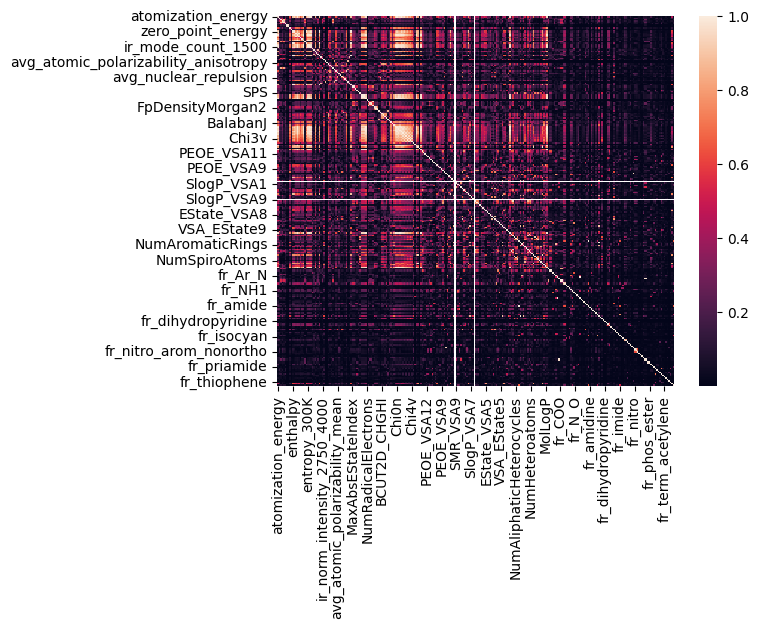

In [59]:
sns.heatmap(corr_matrix)

c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


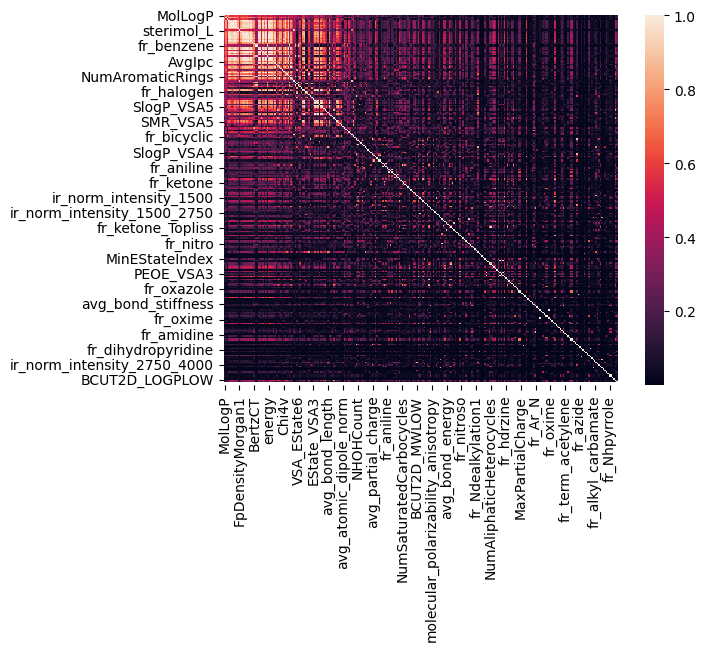

In [39]:
corr_target = X.corrwith(y).abs().sort_values(ascending=False)

sorted_features = corr_target.index
corr_sorted = X[sorted_features].corr()

sns.heatmap(corr_sorted.abs())
plt.show()

In [8]:
np.var(y)

np.float64(5.32633083355637)